In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

In [ ]:
from google.colab import auth
auth.authenticate_user()

In [ ]:
from google.cloud import bigquery
import pandas as pd

In [ ]:
from google.cloud import bigquery
import pandas as pd

PROJECT_ID = "capstone-project-mc"
client = bigquery.Client(project=PROJECT_ID)

In [ ]:
#Loading data from GBQ

query = """
SELECT *
FROM `capstone-project-mc.my_data.covid_data`
"""

df = client.query(query).to_dataframe()

df.head()

,USMER,MEDICAL_UNIT,SEX,PATIENT_TYPE,DATE_DIED,INTUBED,PNEUMONIA,AGE,PREGNANT,DIABETES,...,ASTHMA,INMSUPR,HIPERTENSION,OTHER_DISEASE,CARDIOVASCULAR,OBESITY,RENAL_CHRONIC,TOBACCO,CLASIFFICATION_FINAL,ICU
0,2,1,1,1,03/05/2020,97,1,65,2,2,...,2,2,1,2,2,2,2,2,3,97
1,2,1,2,2,09/06/2020,1,2,55,97,1,...,2,2,2,2,2,2,2,2,3,2
2,2,1,1,2,9999-99-99,2,1,40,2,2,...,2,2,2,2,2,2,2,2,3,2
3,2,1,1,1,9999-99-99,97,2,64,2,2,...,2,2,2,2,2,2,2,2,3,97
4,2,1,1,1,9999-99-99,97,1,64,2,1,...,2,1,1,2,2,2,1,2,3,97


In [ ]:
df.shape


(1048575, 21)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 21 columns):
 #   Column                Non-Null Count    Dtype 
---  ------                --------------    ----- 
 0   USMER                 1048575 non-null  Int64 
 1   MEDICAL_UNIT          1048575 non-null  Int64 
 2   SEX                   1048575 non-null  Int64 
 3   PATIENT_TYPE          1048575 non-null  Int64 
 4   DATE_DIED             1048575 non-null  object
 5   INTUBED               1048575 non-null  Int64 
 6   PNEUMONIA             1048575 non-null  Int64 
 7   AGE                   1048575 non-null  Int64 
 8   PREGNANT              1048575 non-null  Int64 
 9   DIABETES              1048575 non-null  Int64 
 10  COPD                  1048575 non-null  Int64 
 11  ASTHMA                1048575 non-null  Int64 
 12  INMSUPR               1048575 non-null  Int64 
 13  HIPERTENSION          1048575 non-null  Int64 
 14  OTHER_DISEASE         1048575 non-null  Int64 
 15

In [ ]:
df.describe()

,USMER,MEDICAL_UNIT,SEX,PATIENT_TYPE,INTUBED,PNEUMONIA,AGE,PREGNANT,DIABETES,COPD,ASTHMA,INMSUPR,HIPERTENSION,OTHER_DISEASE,CARDIOVASCULAR,OBESITY,RENAL_CHRONIC,TOBACCO,CLASIFFICATION_FINAL,ICU
count,1048575.0,1048575.0,1048575.0,1048575.0,1048575.0,1048575.0,1048575.0,1048575.0,1048575.0,1048575.0,1048575.0,1048575.0,1048575.0,1048575.0,1048575.0,1048575.0,1048575.0,1048575.0,1048575.0,1048575.0
mean,1.632194,8.980565,1.499259,1.190765,79.522875,3.346831,41.794102,49.765585,2.186404,2.260569,2.242626,2.298132,2.128989,2.435143,2.26181,2.125176,2.25718,2.214333,5.305653,79.553974
std,0.482208,3.723278,0.5,0.392904,36.868886,11.912881,16.907389,47.510733,5.424242,5.132258,5.114089,5.462843,5.236397,6.646676,5.19485,5.175445,5.135354,5.323097,1.881165,36.823073
min,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
25%,1.0,4.0,1.0,1.0,97.0,2.0,30.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,3.0,97.0
50%,2.0,12.0,1.0,1.0,97.0,2.0,40.0,97.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,6.0,97.0
75%,2.0,12.0,2.0,1.0,97.0,2.0,53.0,97.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,7.0,97.0
max,2.0,13.0,2.0,2.0,99.0,99.0,121.0,98.0,98.0,98.0,98.0,98.0,98.0,98.0,98.0,98.0,98.0,98.0,7.0,99.0


In [ ]:
df.columns

Index(['USMER', 'MEDICAL_UNIT', 'SEX', 'PATIENT_TYPE', 'DATE_DIED', 'INTUBED',
       'PNEUMONIA', 'AGE', 'PREGNANT', 'DIABETES', 'COPD', 'ASTHMA', 'INMSUPR',
       'HIPERTENSION', 'OTHER_DISEASE', 'CARDIOVASCULAR', 'OBESITY',
       'RENAL_CHRONIC', 'TOBACCO', 'CLASIFFICATION_FINAL', 'ICU'],
      dtype='object')

In [ ]:
df.isna().sum()

,0
USMER,0
MEDICAL_UNIT,0
SEX,0
PATIENT_TYPE,0
DATE_DIED,0
INTUBED,0
PNEUMONIA,0
AGE,0
PREGNANT,0
DIABETES,0


#Data Cleaning
###Reassembling the dataset to make it easier and more fluent to work with.

In [ ]:
#Creating copy

df_clean = df.copy()

In [ ]:
print(df_clean["SEX"].dtype)
print(df_clean["SEX"].unique())

Int64
<IntegerArray>
[1, 2]
Length: 2, dtype: Int64


In [ ]:
df_clean["SEX"] = df_clean["SEX"].astype(str).replace({"1": "Female", "2": "Male"})

In [ ]:
df_clean["AGE"] = pd.to_numeric(df_clean["AGE"], errors="coerce")

In [ ]:
#Formatting the death date for analysis.

df_clean["DATE_DIED_NEW"] = pd.to_datetime(
    df_clean["DATE_DIED"].replace("9999-99-99", pd.NA),
    format="%d/%m/%Y",
    errors="coerce"
)

In [ ]:
print(df_clean["DATE_DIED_NEW"].dropna().sort_values().unique())

<DatetimeArray>
['2020-01-02 00:00:00', '2020-01-03 00:00:00', '2020-01-04 00:00:00',
 '2020-01-05 00:00:00', '2020-01-06 00:00:00', '2020-01-07 00:00:00',
 '2020-01-08 00:00:00', '2020-01-09 00:00:00', '2020-01-10 00:00:00',
 '2020-01-11 00:00:00',
 ...
 '2021-04-22 00:00:00', '2021-04-24 00:00:00', '2021-04-25 00:00:00',
 '2021-04-26 00:00:00', '2021-04-27 00:00:00', '2021-04-28 00:00:00',
 '2021-04-29 00:00:00', '2021-04-30 00:00:00', '2021-05-01 00:00:00',
 '2021-05-02 00:00:00']
Length: 400, dtype: datetime64[ns]


In [ ]:
df_clean["USMER"] = df_clean["USMER"].astype(str).replace({"1": "Primary Care", "2": "General Hospital", "3": "Specialized Care"})

In [ ]:
df_clean["PATIENT_TYPE"] = df_clean["PATIENT_TYPE"].astype(str).replace({"1": "Returned Home", "2": "Hospitalization"})

In [ ]:
df_clean["CLASSIFICATION_FINAL_NEW"] = (
    df_clean["CLASIFFICATION_FINAL"]
    .map({
        1: "Mild",
        2: "Moderate",
        3: "Severe"
    })
    .fillna("Undiagnosed/Inconclusive")
)

In [ ]:
df_clean["INTUBED"] = (
    df_clean["INTUBED"]
    .astype(str)
    .replace({
        "1": 1,
        "2": 0,
        "98": pd.NA,
        "97": pd.NA,
        "99": pd.NA
    })
)

In [ ]:
df_clean["PNEUMONIA"] = (
    df_clean["PNEUMONIA"]
    .astype(str)
    .replace({
        "1": 1,
        "2": 0,
        "98": pd.NA,
        "97": pd.NA,
        "99": pd.NA
    })
)

In [ ]:
df_clean["PREGNANT"] = (
    df_clean["PREGNANT"]
    .astype(str)
    .replace({
        "1": 1,
        "2": 0,
        "98": pd.NA,
        "97": pd.NA,
        "99": pd.NA
    })
)

In [ ]:
df_clean["DIABETES"] = (
    df_clean["DIABETES"]
    .astype(str)
    .replace({
        "1": 1,
        "2": 0,
        "98": pd.NA,
        "97": pd.NA,
        "99": pd.NA
    })
)

In [ ]:
df_clean["COPD"] = (
    df_clean["COPD"]
    .astype(str)
    .replace({
        "1": 1,
        "2": 0,
        "98": pd.NA,
        "97": pd.NA,
        "99": pd.NA
    })
)

In [ ]:
df_clean["ASTHMA"] = (
    df_clean["ASTHMA"]
    .astype(str)
    .replace({
        "1": 1,
        "2": 0,
        "98": pd.NA,
        "97": pd.NA,
        "99": pd.NA
    })
)

In [ ]:
df_clean["INMSUPR"] = (
    df_clean["INMSUPR"]
    .astype(str)
    .replace({
        "1": 1,
        "2": 0,
        "98": pd.NA,
        "97": pd.NA,
        "99": pd.NA
    })
)

In [ ]:
df_clean["HYPERTENSION"] = (
    df_clean["HIPERTENSION"]
    .astype(str)
    .replace({
        "1": 1,
        "2": 0,
        "98": pd.NA,
        "97": pd.NA,
        "99": pd.NA
    })
)

In [ ]:
df_clean["OTHER_DISEASE"] = (
    df_clean["OTHER_DISEASE"]
    .astype(str)
    .replace({
        "1": 1,
        "2": 0,
        "98": pd.NA,
        "97": pd.NA,
        "99": pd.NA
    })
)

In [ ]:
df_clean["CARDIOVASCULAR"] = (
    df_clean["CARDIOVASCULAR"]
    .astype(str)
    .replace({
        "1": 1,
        "2": 0,
        "98": pd.NA,
        "97": pd.NA,
        "99": pd.NA
    })
)

In [ ]:
df_clean["OBESITY"] = (
    df_clean["OBESITY"]
    .astype(str)
    .replace({
        "1": 1,
        "2": 0,
        "98": pd.NA,
        "97": pd.NA,
        "99": pd.NA
    })
)

In [ ]:
df_clean["RENAL_CHRONIC"] = (
    df_clean["RENAL_CHRONIC"]
    .astype(str)
    .replace({
        "1": 1,
        "2": 0,
        "98": pd.NA,
        "97": pd.NA,
        "99": pd.NA
    })
)

In [ ]:
df_clean["TOBACCO"] = (
    df_clean["TOBACCO"]
    .astype(str)
    .replace({
        "1": 1,
        "2": 0,
        "98": pd.NA,
        "97": pd.NA,
        "99": pd.NA
    })
)

In [ ]:
df_clean["ICU"] = (
    df_clean["ICU"]
    .astype(str)
    .replace({
        "1": 1,
        "2": 0,
        "98": pd.NA,
        "97": pd.NA,
        "99": pd.NA
    })
)

In [ ]:
df_clean["DIED"] = np.where(
    df_clean["DATE_DIED_NEW"].notna(),
    1,
    0
)

In [ ]:
#Seperating the indices of the date for future analysis.

df_clean["DATE_DIED_NEW"] = pd.to_datetime(df_clean["DATE_DIED_NEW"], errors="coerce")

df_clean["YEAR"] = df_clean["DATE_DIED_NEW"].dt.year.astype("Int64")
df_clean["MONTH"] = df_clean["DATE_DIED_NEW"].dt.month.astype("Int64")
df_clean["DAY"] = df_clean["DATE_DIED_NEW"].dt.day.astype("Int64")

In [ ]:
df_clean

,USMER,MEDICAL_UNIT,SEX,PATIENT_TYPE,DATE_DIED,INTUBED,PNEUMONIA,AGE,PREGNANT,DIABETES,...,TOBACCO,CLASIFFICATION_FINAL,ICU,DATE_DIED_NEW,CLASSIFICATION_FINAL_NEW,HYPERTENSION,DIED,YEAR,MONTH,DAY
0,General Hospital,1,Female,Returned Home,03/05/2020,<NA>,1,65,0,0,...,0,3,<NA>,2020-05-03,Severe,1,1,2020,5,3
1,General Hospital,1,Male,Hospitalization,09/06/2020,1,0,55,<NA>,1,...,0,3,0,2020-06-09,Severe,0,1,2020,6,9
2,General Hospital,1,Female,Hospitalization,9999-99-99,0,1,40,0,0,...,0,3,0,NaT,Severe,0,0,<NA>,<NA>,<NA>
3,General Hospital,1,Female,Returned Home,9999-99-99,<NA>,0,64,0,0,...,0,3,<NA>,NaT,Severe,0,0,<NA>,<NA>,<NA>
4,General Hospital,1,Female,Returned Home,9999-99-99,<NA>,1,64,0,1,...,0,3,<NA>,NaT,Severe,1,0,<NA>,<NA>,<NA>
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1048570,Primary Care,13,Male,Returned Home,9999-99-99,<NA>,0,28,<NA>,0,...,0,7,<NA>,NaT,Undiagnosed/Inconclusive,0,0,<NA>,<NA>,<NA>
1048571,Primary Care,13,Female,Hospitalization,9999-99-99,0,0,23,0,1,...,0,7,0,NaT,Undiagnosed/Inconclusive,0,0,<NA>,<NA>,<NA>
1048572,Primary Care,13,Male,Returned Home,9999-99-99,<NA>,0,47,<NA>,1,...,0,7,<NA>,NaT,Undiagnosed/Inconclusive,0,0,<NA>,<NA>,<NA>
1048573,General Hospital,13,Male,Returned Home,9999-99-99,<NA>,0,40,<NA>,0,...,0,7,<NA>,NaT,Undiagnosed/Inconclusive,0,0,<NA>,<NA>,<NA>


#EDA

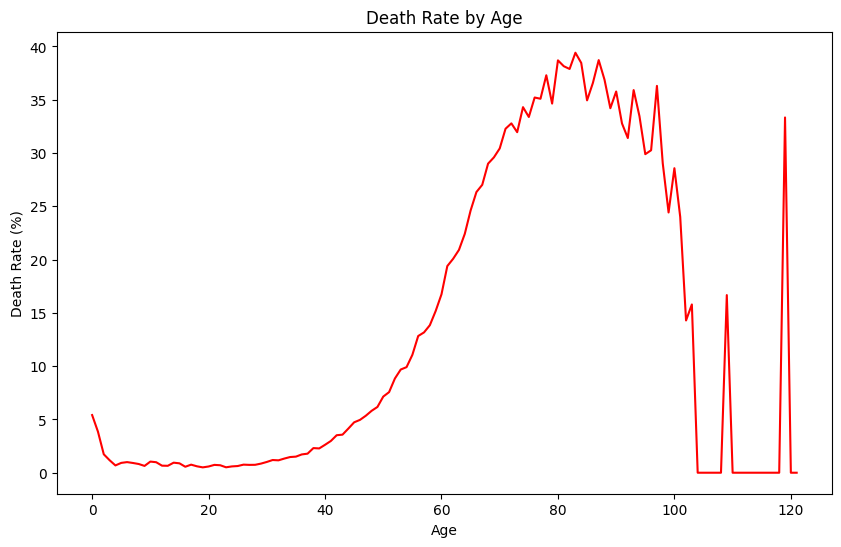

In [ ]:
#Death rate by age

death_rate = (
    df_clean.groupby("AGE")["DIED"]
    .mean()
    .mul(100)
)

death_rate.plot(figsize=(10, 6), color="red")

plt.title("Death Rate by Age")
plt.xlabel("Age")
plt.ylabel("Death Rate (%)")

plt.show()

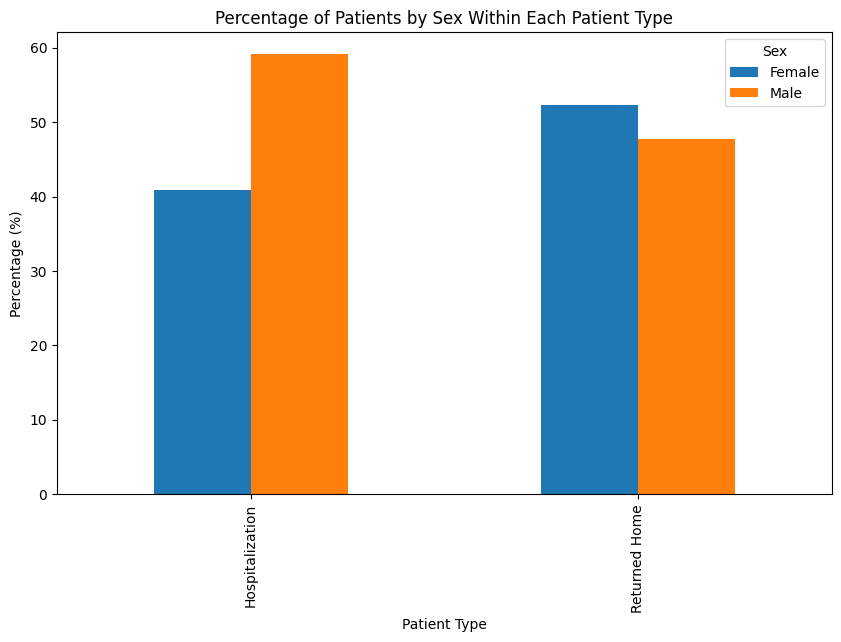

In [ ]:
#Distribution of Patient Type by Gender

usmer_pct = pd.crosstab(
    df_clean["PATIENT_TYPE"],
    df_clean["SEX"],
    normalize="index"
) * 100

usmer_pct.columns = ["Female", "Male"]

usmer_pct.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Percentage of Patients by Sex Within Each Patient Type")
plt.xlabel("Patient Type")
plt.ylabel("Percentage (%)")
plt.legend(title="Sex")

plt.show()

In [ ]:
#Preparing a matrix for the correlations between different diseases and death.

conditions = [
    "PNEUMONIA", "PREGNANT", "DIABETES", "COPD", "ASTHMA",
    "INMSUPR", "HYPERTENSION", "OTHER_DISEASE",
    "CARDIOVASCULAR", "OBESITY", "RENAL_CHRONIC", "TOBACCO"
]

df_clean[conditions] = df_clean[conditions].apply(
    pd.to_numeric,
    errors="coerce"
)

In [ ]:
#Checking for inconsistencies

print(df_clean[conditions].dtypes)

PNEUMONIA         float64
PREGNANT          float64
DIABETES          float64
COPD              float64
ASTHMA            float64
INMSUPR           float64
HYPERTENSION      float64
OTHER_DISEASE     float64
CARDIOVASCULAR    float64
OBESITY           float64
RENAL_CHRONIC     float64
TOBACCO           float64
dtype: object


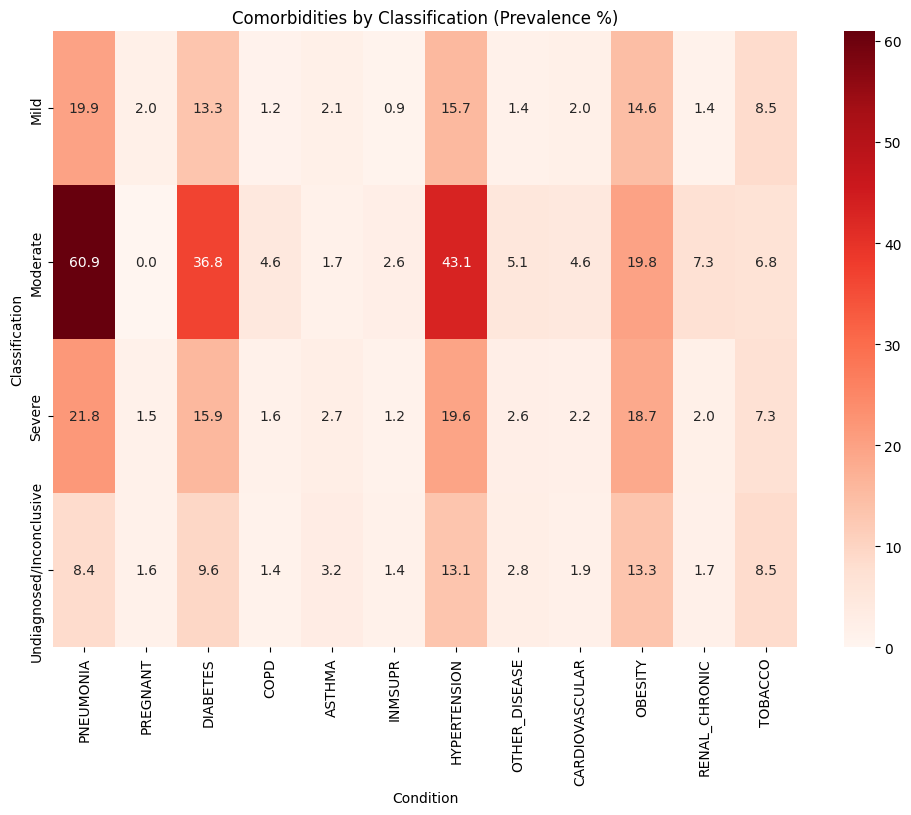

In [ ]:
heatmap_data = (
    df_clean
    .groupby("CLASSIFICATION_FINAL_NEW")[conditions]
    .mean() * 100
)

plt.figure(figsize=(12, 8))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".1f",
    cmap="Reds"
)

plt.title("Comorbidities by Classification (Prevalence %)")
plt.xlabel("Condition")
plt.ylabel("Classification")

plt.show()

#Machine Learning

In [ ]:
#Preparing for logistic regression

features = [
    "PNEUMONIA", "AGE", "DIABETES", "COPD", "ASTHMA",
    "INMSUPR", "HYPERTENSION", "CARDIOVASCULAR",
    "OBESITY", "RENAL_CHRONIC", "TOBACCO"
]

df_model = df_clean[["DIED"] + features].apply(
    pd.to_numeric,
    errors="coerce"
).dropna()


#Group ages by the dozen to improve accuracy.
df_model["AGE"] = df_model["AGE"] / 10

X = df_model[features].astype(float)
y = df_model["DIED"].astype(float)

X = sm.add_constant(X)

In [ ]:
model = sm.Logit(y, X)
result = model.fit(method="lbfgs", maxiter=200)

print(result.summary())

                           Logit Regression Results                           
Dep. Variable:                   DIED   No. Observations:              1026832
Model:                          Logit   Df Residuals:                  1026820
Method:                           MLE   Df Model:                           11
Date:                Tue, 16 Jun 2026   Pseudo R-squ.:                  0.3716
Time:                        18:12:33   Log-Likelihood:            -1.6865e+05
converged:                       True   LL-Null:                   -2.6840e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -6.4742      0.018   -350.271      0.000      -6.510      -6.438
PNEUMONIA          2.6093      0.009    277.689      0.000       2.591       2.628
AGE                0.5566      0.003

In [ ]:
#Preparing for Z-test

from statsmodels.stats.proportion import proportions_ztest

# Clean data
df_test = df_clean[["DIED", "PNEUMONIA"]].dropna()

pneumonia = df_test[df_test["PNEUMONIA"] == 1]["DIED"]
no_pneumonia = df_test[df_test["PNEUMONIA"] == 0]["DIED"]

count = np.array([
    pneumonia.sum(),
    no_pneumonia.sum()
])

nobs = np.array([
    len(pneumonia),
    len(no_pneumonia)
])

#Z-Test
z_stat, p_value = proportions_ztest(count, nobs)

print("Z-statistic:", z_stat)
print("P-value:", p_value)

Z-statistic: 479.1776178264977
P-value: 0.0


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report
from sklearn import tree

# Features
features = [
    "PREGNANT",
    "DIABETES",
    "COPD",
    "ASTHMA",
    "INMSUPR",
    "HYPERTENSION",
    "OTHER_DISEASE",
    "CARDIOVASCULAR",
    "OBESITY",
    "RENAL_CHRONIC",
    "TOBACCO"
]

# Keep only complete observations
df_tree = df_clean[["PNEUMONIA"] + features].dropna()

# X = predictors, y = target
X = df_tree[features]
y = df_tree["PNEUMONIA"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Train decision tree
clf = DecisionTreeClassifier(
    max_depth=4,
    min_samples_leaf=100,
    random_state=42
)

clf.fit(X_train, y_train)

# Predictions
y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.89      1.00      0.94     91077
         1.0       0.00      0.00      0.00     10932

    accuracy                           0.89    102009
   macro avg       0.45      0.50      0.47    102009
weighted avg       0.80      0.89      0.84    102009



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


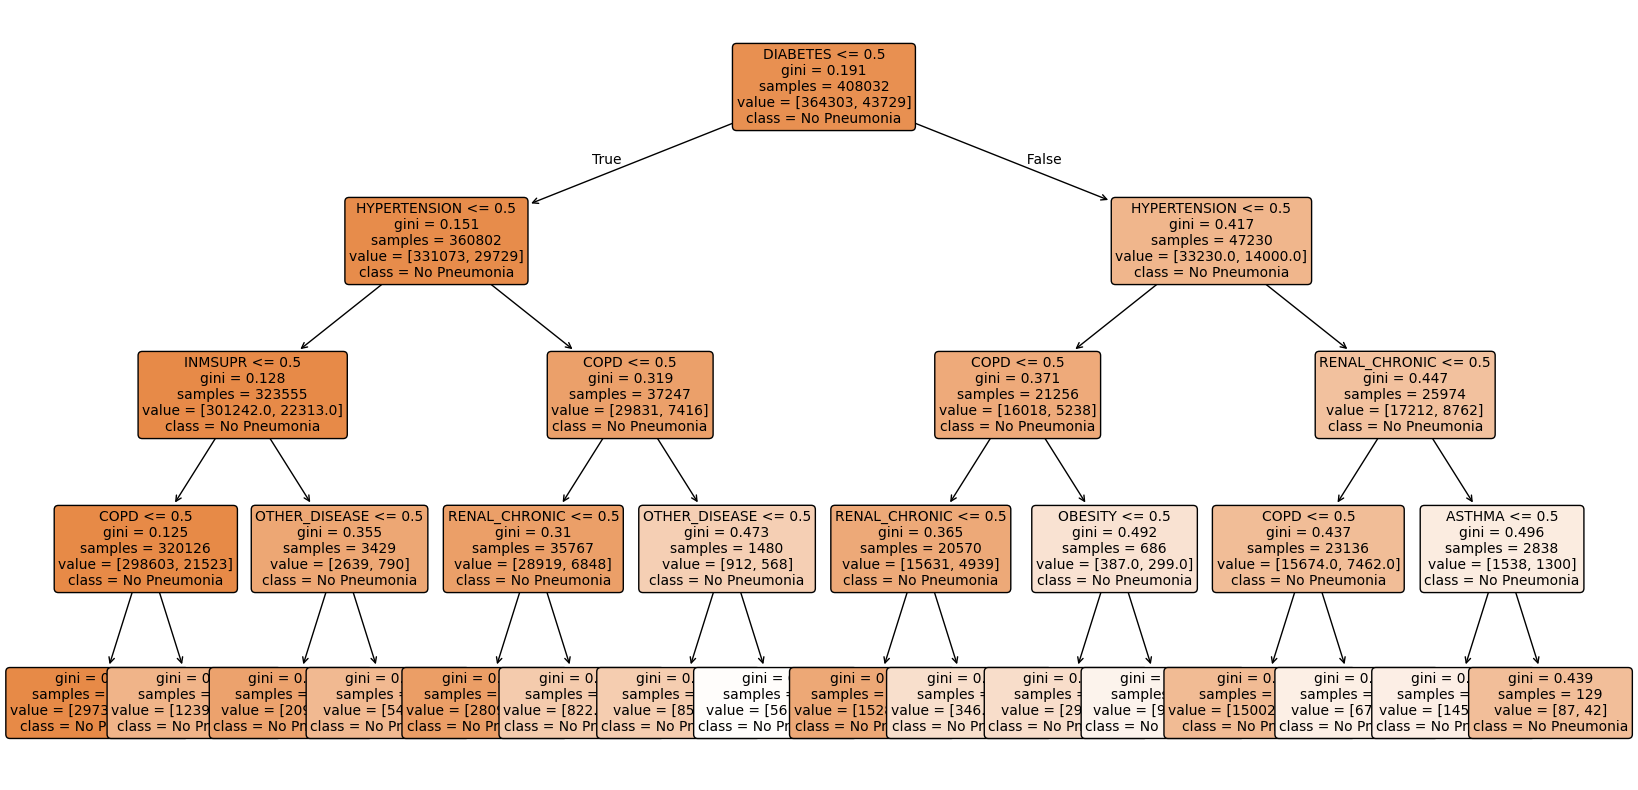

In [ ]:
plt.figure(figsize=(20, 10))

tree.plot_tree(
    clf,
    feature_names=features,
    class_names=["No Pneumonia", "Pneumonia"],
    filled=True,
    rounded=True,
    fontsize=10
)

plt.show()

#Saving Cleaned data

In [ ]:
from pandas_gbq import to_gbq

to_gbq(
    df_clean,
    destination_table='my_data.covid_data_cleaned',
    project_id='capstone-project-mc',
    if_exists='replace'
)

100%|██████████| 1/1 [00:00<00:00, 7516.67it/s]


In [ ]:
df_clean.to_csv('covid_data_clean.csv', index=False)

from google.colab import files
files.download('covid_data_clean.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>